# Exercise 10-1: Create a Linear Regression Model on Fish Data

This Notebook is a cleaned version of [this notebook](ex_10-1_fish.ipynb)

## Setup and Load Data

1. Import Libraries, Modules, and Functions

Beginning by importing the required tools:

- `pandas`: data structuring
- `seaborn`: statistical visualization
- `LinearRegression` from `sklearn.linear_model`: build predictive model
- `train_test_split` from `sklearn.selection`: properly split data for training and validation
- `matplotlib.pyplot`: provide the foundational plotting engine used by `seaborn` to customize titles, labels, and figure structures

In [69]:
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

2. Load Data

Loading the `Fish.csv` file into a Pandas DataFrame object named `fish`
- `pd.read_csv()` reads a csv file into a structured DataFrame
- `head()` displays the first 5 rows of the dataset to check that the columns and data have loaded correctly

In [70]:
fish = pd.read_csv(r'..\data\Fish.csv')

## Exploratory Data Analysis (EDA) *new*
`.shape` display the number of rows and columns.
    - `[0]` as rows
    - `[1]` as columns

In [71]:
fish.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [72]:
print(f"Number of row: {fish.shape[0]}\nNumber of column: {fish.shape[1]}")

Number of row: 159
Number of column: 7


In [73]:
fish.isnull().sum() # check for missing values

Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

In [74]:
fish.describe()

,Weight,Length1,Length2,Length3,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,26.247170,28.415723,31.227044,8.970994,4.417486
std,357.978317,9.996441,10.716328,11.610246,4.286208,1.685804
min,0.000000,7.500000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,19.050000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,25.200000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,32.700000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,59.000000,63.400000,68.000000,18.957000,8.142000


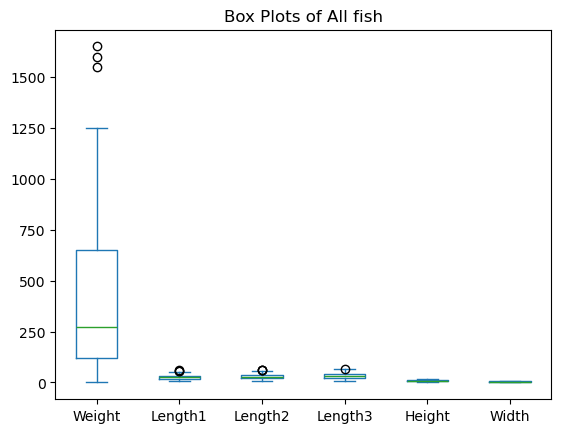

In [75]:
fish.plot(kind='box', layout=(2,2), sharex=False, sharey=False).set_title("Box Plots of All fish");

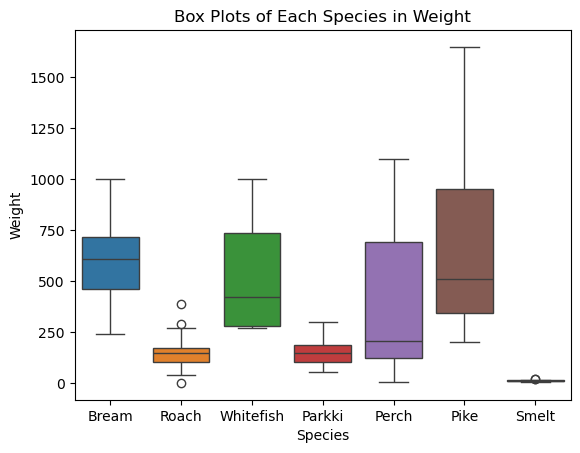

In [76]:
sns.boxplot(data=fish, x=fish['Species'], y=fish['Weight'], hue='Species').set(title='Box Plots of Each Species in Weight');

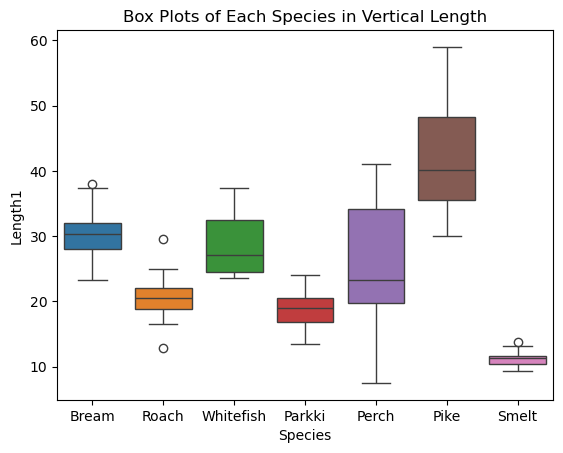

In [77]:
sns.boxplot(data=fish,x = fish['Species'], y=fish['Length1'], hue=fish['Species']).set(title='Box Plots of Each Species in Vertical Length');

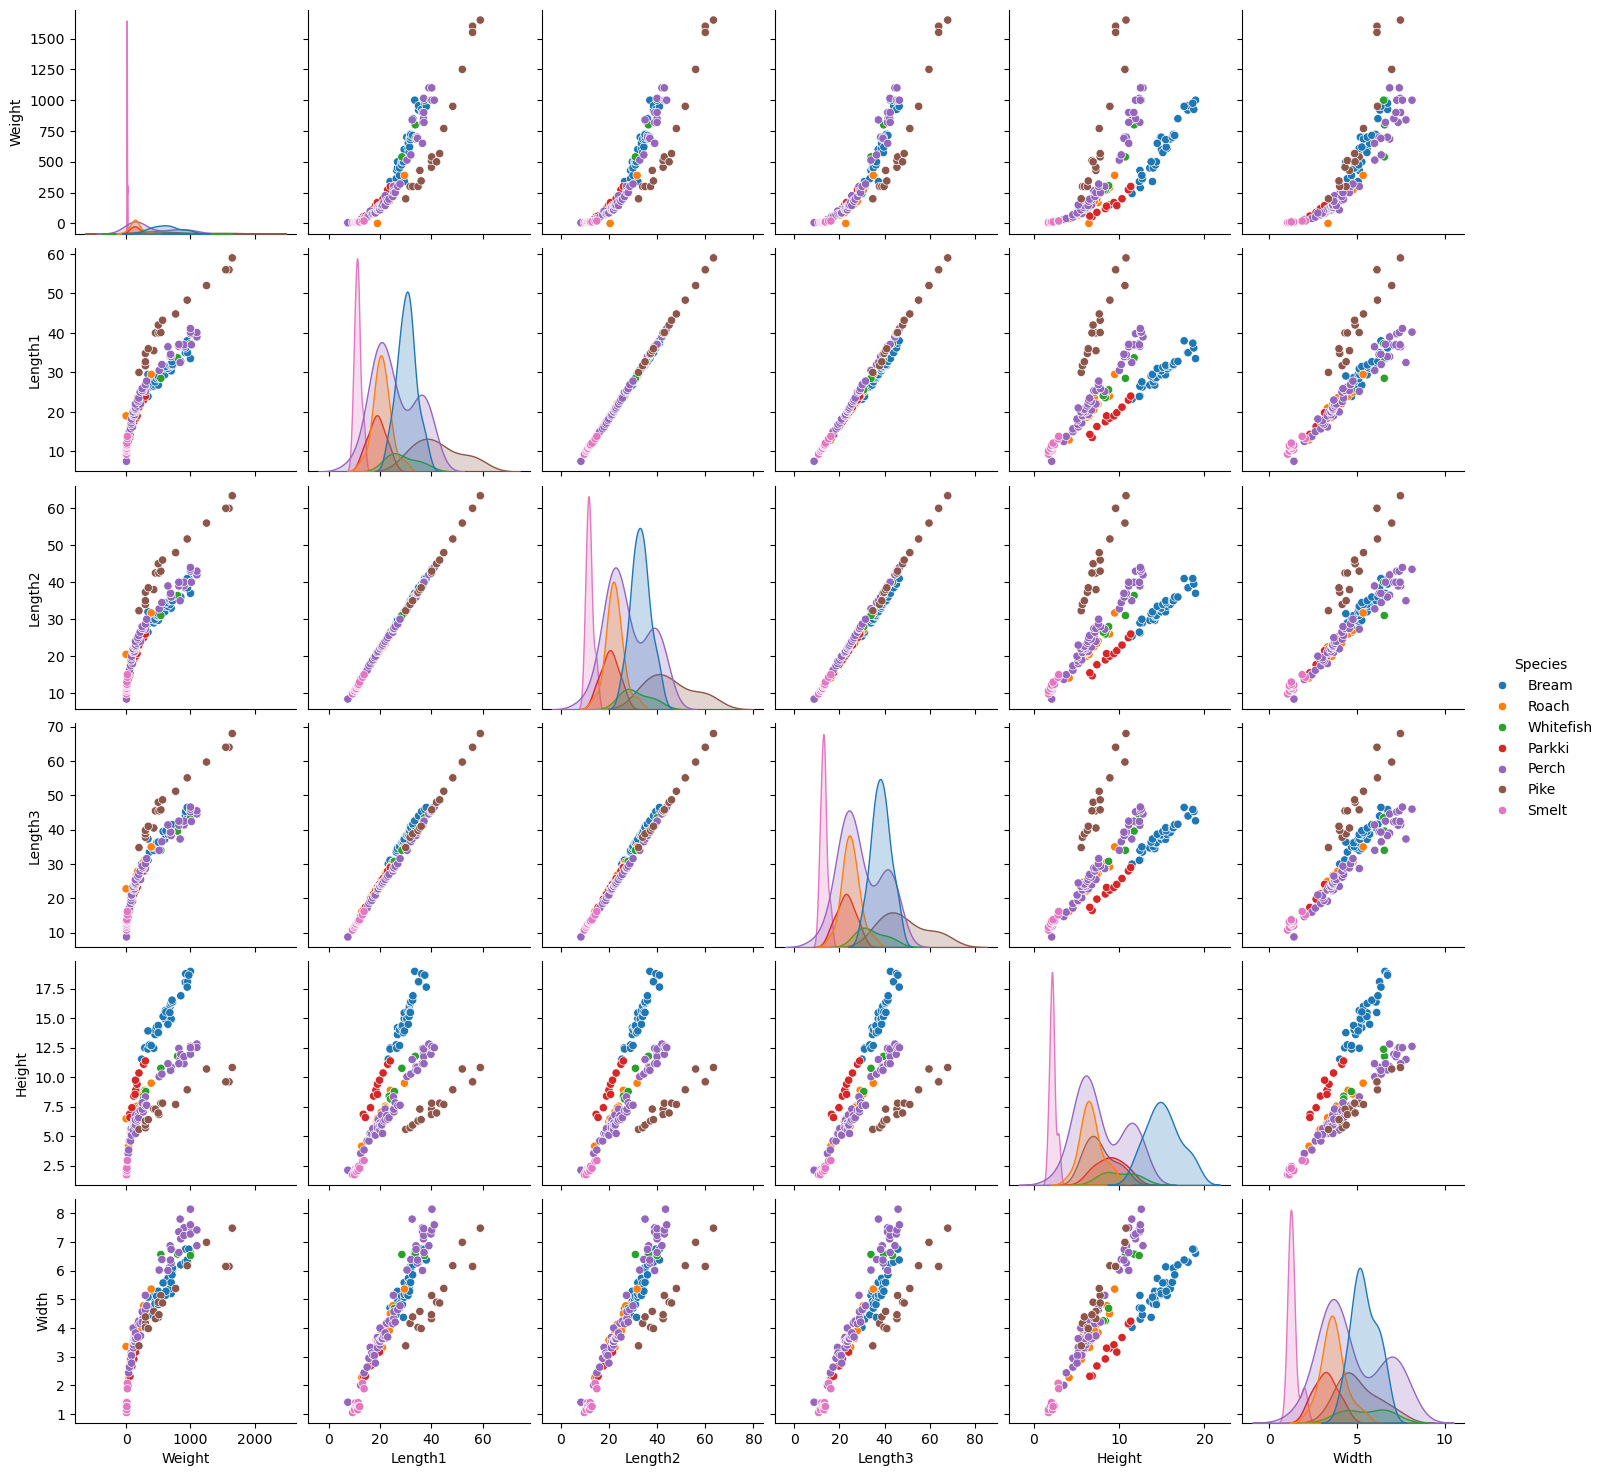

In [78]:
sns.pairplot(data=fish, hue="Species");

## Clean the Data

**Rename Columns for Better Descriptions**

The original dataset usese the generic labels `Length1`, `Length2`, and `Length3`. To make the dataset self-documenting and easier to analyze, we rename these columns to `VerticalLength`, `DiagonalLength`, and `CrossLength` respectively.

**Code Explanation**

`.rename(columns=...)` accepts a dictionary mapping old column headers to new string names

In [79]:
## Mapping new names to old column names
new_names = {
    'Length1': 'VerticalLength',
    'Length2': 'DiagonalLength',
    'Length3': 'CrossLength'
}

fish = fish.rename(columns=new_names) # renaming based on the mapping
fish.head() # verify the renaming

,Species,Weight,VerticalLength,DiagonalLength,CrossLength,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [80]:
# fish.to_csv('Fish.csv', index = False) # save cleaned dataset

## Identify a Correlation

- **Isolate Numerical Data**: Linear regression requires numerical inputs. Therefore, subseting the DataFrame to separate the continuous variables from the categorical variable (`Species`).
- **Compute the Correlation Matrix**: Evaluating how strongly each physical feature relates to the fish's `Weight` by generating a **correlation matrix** in descending order. 
- **Code Explanation**:
    - The double brackets (`[[...]]`) are used in Pandas to select a list of specific column names, returning a new DataFrame subset.
    - `.corr()` computes the pairwise Pearson correlation coefficients between all numeric columns. Subsetting with `[['Weight]]` focuses exclusively on the relationship of features against our target variable, and `.sort_values(by='Weight', ascending=False)` orders them from strongest positive relationship to weakest.

In [81]:
fish_numeric = fish[['Weight', 'VerticalLength', 'DiagonalLength', 'CrossLength', 'Height', 'Width']]
fish_numeric.corr()[['Weight']].sort_values(by='Weight', ascending=False)

,Weight
Weight,1.000000
CrossLength,0.923044
DiagonalLength,0.918618
VerticalLength,0.915712
Width,0.886507
Height,0.724345


**Interpretation of the Correlation Matrix**

- Pearson correlation values range from -1 to 1, where `1` represents a perfect positive linear relationship, `-1` a perfect negative linear relationship, and `0` no linear relationship.
- `CrossLength` (0.923), `DiagonalLength` (0.9186), and `VerticalLength` (0.9157) show exceptionally strong positive linear correlations with `Weight`. 
- `Width` (0.8865) and `Height` (0.7243) also share a strong positive relationship with `Weight`, though slightly less intense than the length measurements.

**Conclusion**: Since all features share high positive correlation coefficients with `Weight`, we expect a fish's weight to predictably scale upwards as any of these spatial dimensions increase.

### Visualize via a Heatmap

To easily see the overall dataset relationships and check for potential multi-collinearity, we plot the full correlation matrix as a color-coded heatmap.

**Code Explanation**
- `plt.figure(figsize=(8, 6))` configures the display dimensions of our output plot.

- `sns.heatmap()` generates the color grid.

- `cmap='coolwarm'` sets the color spectrum (blue for negative, red for positive).

- `fmt=".4f"` forces the decimal values inside each block to display to 4 decimal places.

- `vmin` and `vmax` anchor the spectrum boundaries safely between -1 and 1.

- `plt.show()` forces the visual rendering.

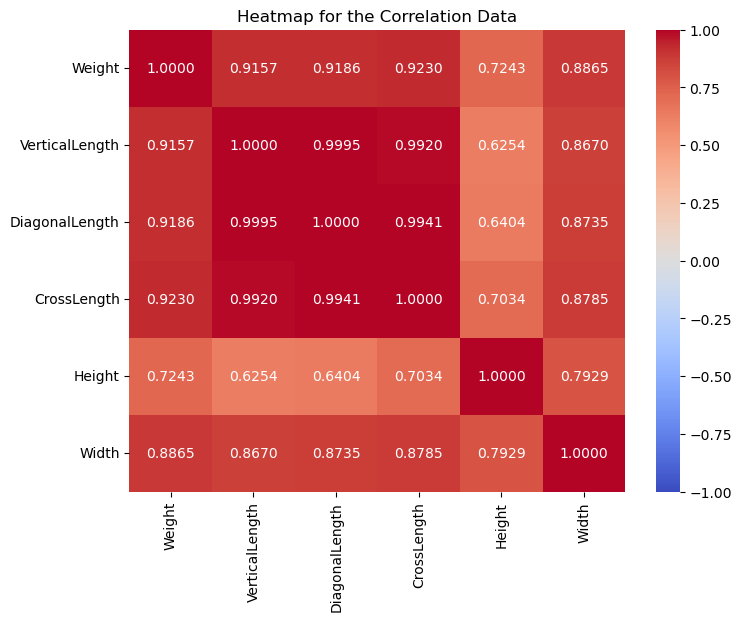

In [82]:
plt.figure(figsize=(8, 6))
sns.heatmap(fish_numeric.corr(), annot=True, cmap='coolwarm', fmt=".4f", vmin=-1, vmax=1)
plt.title('Heatmap for the Correlation Data')
plt.show()

### Visualize via Scatter Plots

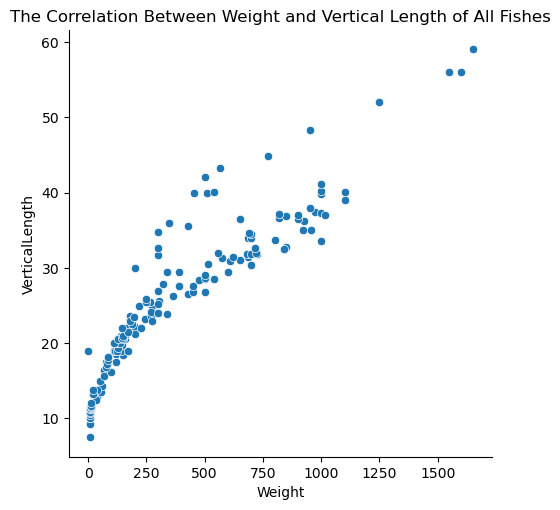

In [83]:
sns.relplot(data=fish_numeric, x="Weight", y="VerticalLength").set(title="The Correlation Between Weight and Vertical Length of All Fishes");

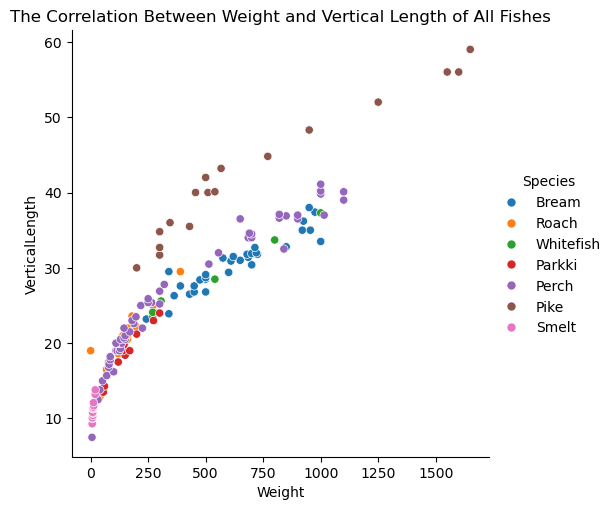

In [84]:
sns.relplot(data=fish, x="Weight", y="VerticalLength", hue='Species').set(title="The Correlation Between Weight and Vertical Length of All Fishes");

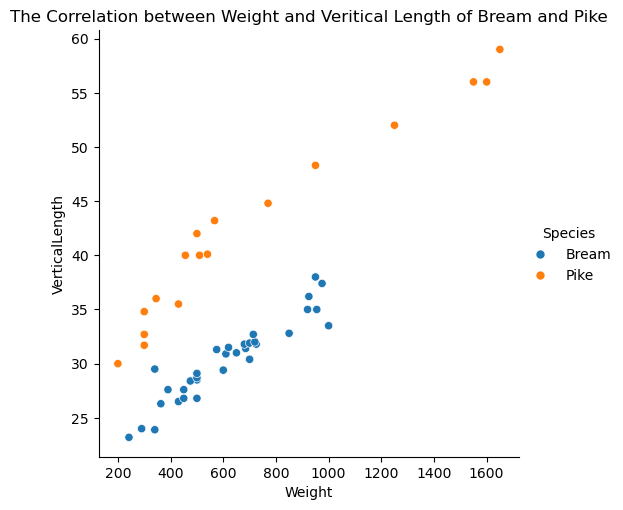

In [85]:
sns.relplot(data=fish[fish['Species'].isin(['Pike', 'Bream'])]
, x='Weight', y='VerticalLength', hue='Species').set(title='The Correlation between Weight and Veritical Length of Bream and Pike');

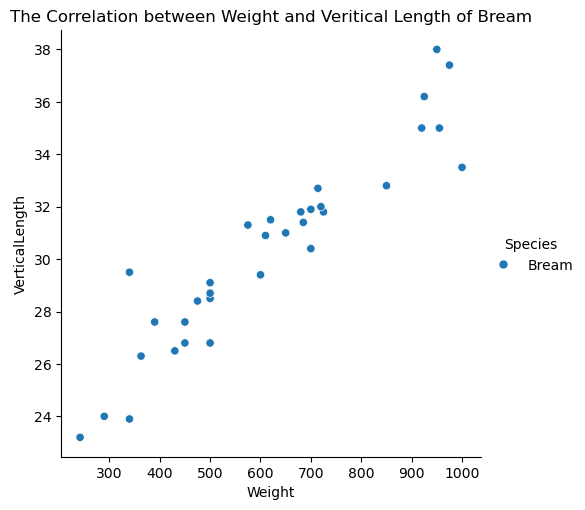

In [86]:
sns.relplot(data=fish[fish['Species']=='Bream'], x='Weight', y='VerticalLength', hue='Species').set(title='The Correlation between Weight and Veritical Length of Bream');

**Interpretation for Scatter Plots**

All scatter plots display positive and non-linear plot

## Perform the Linear Regression
**Filter the Data with only Bream Species**

**Separate the Target and Feature Variables**

Before constructing a linear regression model targeting `Weigth` ($Y$) using highly correlated feature, `VerticalLength` ($X$).

**Split the Dataset into Training and Testing Sets**

To ensure the model generalizes well to new, *unseen* data, we must split data using a 67/33 ratio. 67% will be utilized to train the model coefficients, while 33% will be reserved to evaluated performance for the trained model. 

**Code Explanation** 
- `.query("Species=='Bream'")` filter out everything except for `Bream` species 
- `train_test_split()` shuffles and divides the matrices.
- `test_size=0.33` allocates exactly 33% of rows to the test sets (`_test`).
- `random_state=42` initializes a pseudo-random seed, guaranteeing that this exact data split reproduces perfectly on any machine.

In [87]:
bream = fish.query("Species=='Bream'")
print(f"Number of Bream: {len(bream)} fishes")

x = bream[['VerticalLength']] # feature
y = bream[['Weight']] # target

# split train and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=42)
print(f"Number of Training data: {len(x_train)}")
print(f"Number of Testing data: {len(x_test)}")

Number of Bream: 35 fishes
Number of Training data: 23
Number of Testing data: 12


**3. Train the Linear Regression Model**

Instantiating scikit-learn `LinearRegression` object and fit it onto training subsets

**Code Explanation**
* `LinearRegression()` constructs the blank model structure.
* `.fit(x_train, y_train)` applies Ordinary Least Squares (OLS) to solve for the line configuration that minimizes squared error.
* `.intercept_` and `.coef_ store` the calculated values for the constant ($c$) and slope ($m$) of our line ($Y = mX + c$).

In [88]:
# create the model and fit the training data (Hint: To create use LinearRegression() and to fit use .fit() )

linearModel = LinearRegression()
linearModel.fit(x_train, y_train)

print(f"Intercept: {linearModel.intercept_[0]:.4f}")
print(f"Coefficient: {linearModel.coef_[0][0]:.4f}")

Intercept: -968.6683
Coefficient: 52.3706


**Interpretation of Model Coefficient**

- **Intercept (-968.6683)**: This represents the theoretical baseline prediction for Weight when `VerticalLength` is exactly 0. While a negative mass is physically impossible for a fish, this structural calculation serves to correctly calibrate the linear trajectory across the observed spatial limits of our data.

- **Coefficient / Slope (52.3706)**: This tells the rate of change. For every additional 1 centimeter increase in a fish's `VerticalLength`, the model predicts that the fish's `Weight` will increase by approximately **52.37 grams** for a Bream

**4. Validate the Model and Evaluate R-Squared**

Checking how much variance the calculated formula accounts for when applied to the independent validation test tracking data.

**Code Explanation**: `.score()` automatically takes the provided feature metrics, runs them through the mathematical model line, outputs predictions, and evaluates them against the true values using the Coefficient of Determination ($R^2$).

In [89]:
train_score = linearModel.score(x_train, y_train)
test_score = linearModel.score(x_test, y_test)

print(f'Training R-Squared = {train_score:.4f}')
print(f'Testing R-Squared  = {test_score:.4f}')

Training R-Squared = 0.9327
Testing R-Squared  = 0.7321


**Interpretation of the R-Squared**
- **Training $R^2$ (0.9327)**: Approximately **93.27%** of the variance in fish weight is successfully explained by the `VerticalLength` variable within our training dataset.
- **Testing $R^2$ (0.7321)**: When evaluated against completely unseen test data, the model still explains **73.21%** of the variance in weight.

**Conclusion**:  The drop ($\approx 20\%$) between training accuracy ($0.9327$) and testing accuracy ($0.7321$) shows that while the model captures a strong linear signal, it exhibits clear signs of **mild overfitting**. Because we filtered our dataset to focus exclusively on Bream, our sample size was smaller. This caused the model to memorize the specific characteristics of the training subset (of Bream) too closely, causing a slight drop in accuracy when making predictions on new data.

**5. Generate Weight Predictions**

Using the finalized testing partitions, display the trained model's official predictions. 

**Code Explanation** `.predict()` feeds the test feature matrix (`x_test`) into our calculated linear equationi to yield a fresh array of estimated values.

In [90]:
# make the predictions (Hint: Use .predict() save results of this to y_predicted)
# use the model to make predictions

y_predicted = linearModel.predict(x_test)

## Plot the Regression Line

**Consolidate Results into a Final DataFrame**

Collecting the independent features, actual observations, and model predictions into a single structured DataFrame to easily prepare them for visualization.

**Code Explanation**: 
* `.reset_index(drop=True)` drops index constraints to line up dataframe rows cleanly.
* `.join()` merges independent columns side-by-side.
* `final['PredictedWeight'] = y_predicted` appends the calculated numpy predictions array as a new DataFrame column.

In [91]:
final = x_test.reset_index(drop=True).join(y_test.reset_index(drop=True)) # join the predicted data with the original data
final['PredictedWeight'] = y_predicted
final = final.rename(columns={'Weight': 'ActualWeight'}) # rename to ActualWeight
final.head()

,VerticalLength,ActualWeight,PredictedWeight
0,32.0,720.0,707.192175
1,29.5,340.0,576.265578
2,31.9,700.0,701.955111
3,31.4,685.0,675.769792
4,29.4,600.0,571.028514


**Melt the DataFrame for Seaborn Visualization**

To generate an advanced comparison plot using `sns.replot()`, we reshape our wide tracking parameters into a long variable configuation. 

**Code Explanation** `pd.melt()` transforms a DataFrame from a wide format to a long format. The `id_vars` column remains unchanged, while columns listed in `value_vars` are unpivoted into two new columns: one holding the original header name (`Variable`), and one holding its row measurement (`Value`).

In [92]:
# melt the actual and predicted data (All thats needed here is for you to fill
# in the missing values that go inside the value_vars. Look and see for 
# yourself, value_vars is an empty list right now. Which column names go 
# inside of it? Everything else is already done for you)

finalMelt = pd.melt(final, id_vars=['VerticalLength'], 
                    value_vars=['ActualWeight', 'PredictedWeight'], 
                    var_name='Variable', value_name='Value')
finalMelt.head()

,VerticalLength,Variable,Value
0,32.0,ActualWeight,720.0
1,29.5,ActualWeight,340.0
2,31.9,ActualWeight,700.0
3,31.4,ActualWeight,685.0
4,29.4,ActualWeight,600.0


**Plot the Model's Fits Against Actual Observations**

We visualize our linear model's track directly alongside the original test data observations.

**Code Explanation**: `sns.relplot()` creates a statistical scatter plot. Setting `hue='Variable'` splits our data markers into distinct colors based on whether they represent real world measurements (`ActualWeight`) or our calculated line points (`PredictedWeight`), which will clearly form a straight line path.

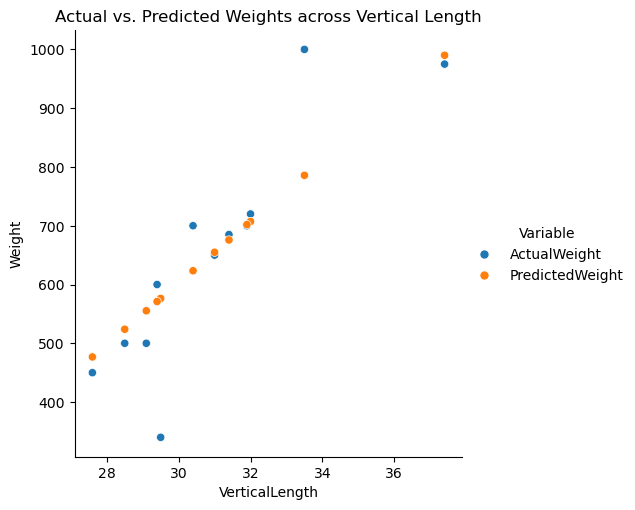

In [ ]:
# use relplot() to plot the actual and predicted data (Hint: the data parameter 
# should be set like this data=finalMelt, and x='VerticalLength', y='Value', 
# hue='Variable')

sns.relplot(data=finalMelt, x='VerticalLength', y='Value', hue='Variable', kind='scatter')
plt.title('Actual vs. Predicted Weights across Vertical Length')
plt.ylabel('Weight')
plt.show()

**Interpretation**

- The `PredictedWeight` data poins align prefectly to form a straight line, while the `ActualWeight` points are scattered around it. 
- At shorter lengths (26cm to 31cm), the actual weights systematically drop below model's line, meaning the model is **overprediciting** weight in this range.
- In constast, at the upper extreme (above 37cm), the real data points spike sharply above the line, showing the model is **underpredicting** weight for larger fish. This clear pattern demonstrates the straight line is losing tack of real-world weight variations at both ends of the length scale.

**Conclusion**

This plot is a case of **underfiting due to structureal bias (non-linearity)**, rather than overfitting. 

To verify a single feature trajectory across the data, the `lmplot()` function from Seaborn displays a linear fit alongside the filtered Bream subset data points.

**Code Explanation** 
- `sns.lmplot()` automatically calculates and overlays a linear regression trend line and its confidence interval directly on top of a scatter plot. The argument `line_kws={'color': 'red'}` changes the color of the trend line to red.

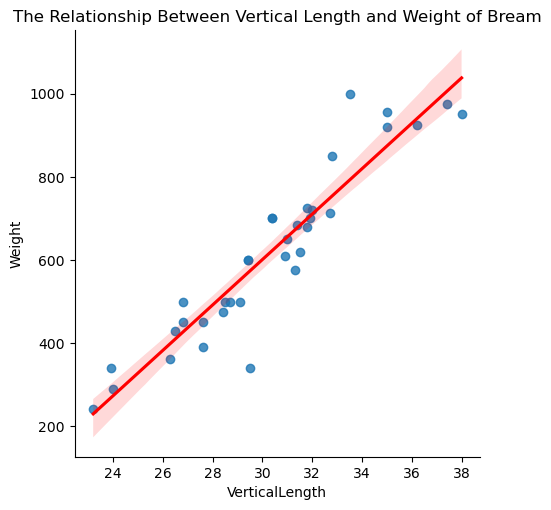

In [ ]:
# use lmplot() to produce a similar result (Hint: set your parameters like this data=bream, x='VerticalLength', y='Weight')
# NOTE: Notice the DataFrame named bream is used with this method

sns.lmplot(data=bream, x='VerticalLength', y='Weight', line_kws={'color':'red'}).set(
    title='The Relationship Between Vertical Length and Weight of Bream'); #plotting a linear regression

**Interpretation**
- Looking at the complete Bream data profile reveals a clear, upward trend: as length increases, weight increases.
- However, looking closely at the plot shows that the actual data points follow adistinct curve—forming a subtle exponential "J-curve"—rather than a perfectly straight line. The straight regression line cuts *under* the data points at the very beginning, crosses over them in the middle, and cuts *under* them again at the largest sizes. This mismatch proves that a simple linear equation cannot keep up with the changing rate of weight growth across a fish's life cycle.

## Plot the Residuals

**Calculate Residual Values**

A residual is the exact difference between the actual observed value and the value predicted by our regression line ($e = y - \hat{y}$). Plotting residuals helps us verify if our model satisfies the linear regression assumption of constant error variance (homoscedasticity).

In [56]:
final['Residual'] = final['ActualWeight'] - final['PredictedWeight'] # calculate the residuals & store them in a column
final.head()

,VerticalLength,ActualWeight,PredictedWeight,Residual
0,32.0,720.0,707.192175,12.807825
1,29.5,340.0,576.265578,-236.265578
2,31.9,700.0,701.955111,-1.955111
3,31.4,685.0,675.769792,9.230208
4,29.4,600.0,571.028514,28.971486


**Generate a Residual Scatter Plot**

Mapping out the calcuated residuals against the independent variable

**Code Explanation**
* `sns.relplot()` maps out coordinate points for errors.
* `plt.axhline(y=0, ...)` draws a reference baseline at zero error. Points resting directly on this line represent perfect predictions.

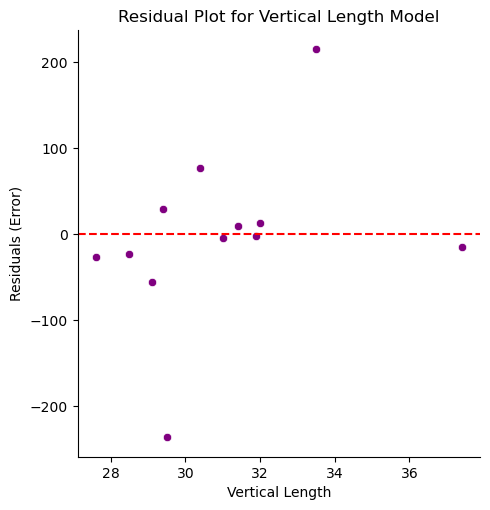

In [ ]:
# use relplot() to create a scatterplot for residuals
sns.relplot(data=final, x='VerticalLength', y='Residual', color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot for Vertical Length Model')
plt.xlabel('Vertical Length')
plt.ylabel('Residuals (Error)')
plt.show()

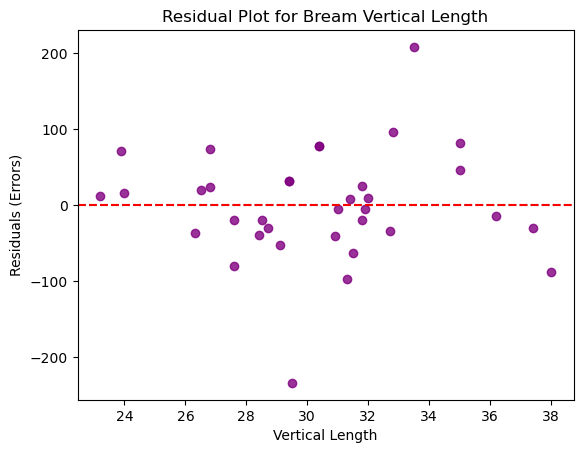

In [ ]:
# use residplot() to produce a similar result
# NOTE: use the DataFrame named bream with this method

sns.residplot(data=bream, x='VerticalLength', y='Weight', color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot for Bream Vertical Length')
plt.xlabel('Vertical Length')
plt.ylabel('Residuals (Errors)')
plt.show()

**Interpretation for Residuals Plots**

For a linear regression model to be statistically valid, its residual plot should show points randomly scattered around the zero line like a uniform cloud. This would confirm that our model's errors are random and unbiased.

However, your Bream residual plot shows a highly distinct **U-shaped parabolic curve**. The errors start high, drop deeply below zero for medium-length fish, and spike back up for long fish.

This non-random pattern is clear evidence of **non-linearity**. It tells us that our model suffers from systemic structural bias because it assumes a perfectly straight growth rate, causing it to consistently overestimate the weight of medium-sized fish and underestimate the weight of small and large fish.

## Conclusion

**Summary of Activities**

In this data science notebook analysis, we executed a complete end-to-end predictive workflow using ordinary least squares (OLS) linear regression on a fish dataset. Our workflow focused on importing and inspecting the data, checking for completeness via missing value audits, and performing exploratory data analysis (EDA) to understand feature boundaries and relationships. After revealing exceptionally strong correlations between fish dimensions and mass, we applied targeted filtering to isolate the **Bream** species. We then partitioned our records into an operational 67% training and 33% testing split before training, validating, and generating diagnostic scatter and residual plots.

**Key Results & Structural Findings**
- **Strong Linear Foundation**: Our exploratory analysis confirmed that all physical dimensions share an incredibly strong positive relationship with weight (r>0.88), proving that spatial metrics are excellent candidate features for predicting fish mass.

- **Fitted Model Parameters**: Our Bream-specific OLS model yielded an Intercept of -968.6683 and a Slope Coefficient of 52.3706. This means that within our model's operational window, every additional 1 centimeter of VerticalLength yields a predictable weight gain of 52.37 grams.

- **Excellent Training Performance with Mild Overfitting**: The model achieved a high level of accuracy on our training subset, with a **Training R 
2
  of 0.9327** (explaining 93.27% of weight variance). However, when evaluated on unseen test data, our accuracy dropped to a **Testing R 
2
  of 0.7321**. While an accuracy of ~73.2% is still quite strong, this notable drop indicates that focusing exclusively on a single species reduced our data volume enough to cause mild overfitting to our training sample.

- **Violation of Core Linear Assumptions**: Most importantly, our diagnostic visualizations (relplot, lmplot, and residplot) all revealed a prominent, repeating U-shaped curve in our model's prediction errors. This clear pattern proves that our errors are not random, meaning our model violates the fundamental linear regression assumption of homoscedasticity.

**Final Takeaway & Next Steps**

While our simple linear regression model provides a helpful baseline that captures the general upward trend of Bream growth, **it is fundamentally limited because it forces a perfectly straight line onto a curving relationship**. In the real world, an organism's weight scales quadratically or exponentially relative to its length as it grows in multiple dimensions.

To resolve this structural bias and significantly improve our predictive accuracy in future iterations, we should move away from simple straight-line equations. Instead, we should implement a **Polynomial Regression model** (by adding a squared length term, Length 
2
 ) or expand our model into a **Multiple Linear Regression framework** that incorporates our highly correlated body Width and Height features alongside length.